In [1]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
from customlayer import MyLayerNorm
import matplotlib.pyplot as plt
import keras_tuner as kt
import os
from pathlib import Path
from functools import partial

In [2]:
# Load the dataset
(X_train_all, y_train_all), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_valid, y_valid = X_train_all[-5000:], y_train_all[-5000:]
X_train, y_train = X_train_all[:-5000], y_train_all[:-5000]

In [3]:
X_train = (X_train / 255.)
X_valid = (X_valid / 255.) 
X_test = (X_test / 255.)

In [2]:
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same", 
                        activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[32, 32, 3]), 
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.LayerNormalization(axis=[1, 2, 3]),
    DefaultConv2D(filters=128), 
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(units=64, activation="relu", 
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])                      

/Users/josephhorzempa/anaconda3/envs/math474/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model2 = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[32, 32, 3]), 
    tf.keras.layers.MaxPool2D(),
    MyLayerNorm(axis=[1, 2, 3]),
    DefaultConv2D(filters=128), 
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(units=64, activation="relu", 
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])  

In [5]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [6]:
history = model.fit(
        X_train, y_train, 
        epochs=100,
        validation_data=(X_valid, y_valid), 
        callbacks=[early_stopping_cb],
        batch_size=128
    )

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 223ms/step - accuracy: 0.1775 - loss: 2.2480 - val_accuracy: 0.3598 - val_loss: 1.8183
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 222ms/step - accuracy: 0.3171 - loss: 1.8784 - val_accuracy: 0.4614 - val_loss: 1.5261
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.4110 - loss: 1.6418 - val_accuracy: 0.5128 - val_loss: 1.3909
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.4740 - loss: 1.4742 - val_accuracy: 0.5674 - val_loss: 1.2577
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 221ms/step - accuracy: 0.5200 - loss: 1.3581 - val_accuracy: 0.5954 - val_loss: 1.1678
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 224ms/step - accuracy: 0.5618 - loss: 1.2446 - val_accuracy: 0.6162 - val_loss: 1.1059
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 223ms/step - accuracy: 0.5923 - loss: 1.1628 - val_accuracy: 0.6346 - val_loss: 1.0613
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 224ms/step - accuracy: 0.6233 -

In [8]:
optimizer2 = tf.keras.optimizers.Adam(learning_rate=0.0001)
early_stopping_cb2 = tf.keras.callbacks.EarlyStopping(patience=10)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer2, metrics=["accuracy"])

In [9]:
history2 = model2.fit(
        X_train, y_train, 
        epochs=100,
        validation_data=(X_valid, y_valid), 
        callbacks=[early_stopping_cb2],
        batch_size=128
    )

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 223ms/step - accuracy: 0.1856 - loss: 2.2408 - val_accuracy: 0.3770 - val_loss: 1.7442
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 223ms/step - accuracy: 0.3407 - loss: 1.8136 - val_accuracy: 0.4800 - val_loss: 1.4768
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 77s 217ms/step - accuracy: 0.4257 - loss: 1.5959 - val_accuracy: 0.5274 - val_loss: 1.3419
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 220ms/step - accuracy: 0.4773 - loss: 1.4681 - val_accuracy: 0.5654 - val_loss: 1.2313
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 223ms/step - accuracy: 0.5240 - loss: 1.3527 - val_accuracy: 0.5892 - val_loss: 1.1550
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.5557 - loss: 1.2672 - val_accuracy: 0.6090 - val_loss: 1.1354
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 77s 219ms/step - accuracy: 0.5810 - loss: 1.1959 - val_accuracy: 0.6342 - val_loss: 1.0523
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 111s 316ms/step - accuracy: 0.6141 

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

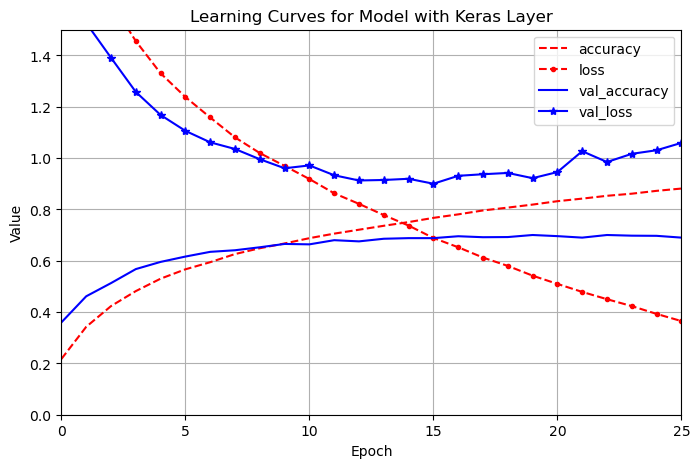

In [18]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 25], ylim=[0, 1.5], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.title("Learning Curves for Model with Keras Layer")
plt.ylabel("Value")
plt.show()

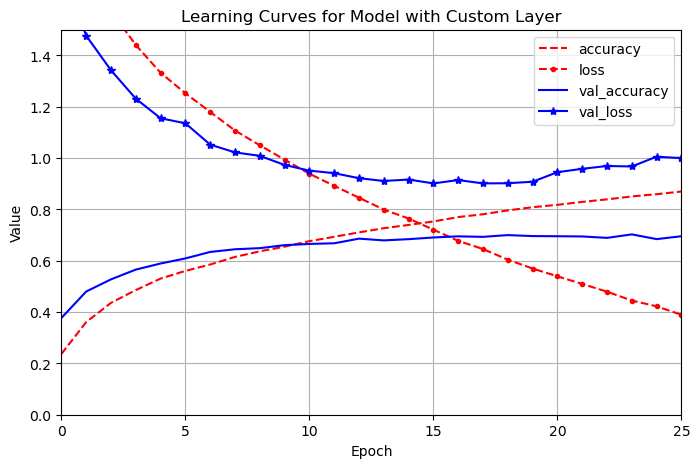

In [26]:
pd.DataFrame(history2.history).plot(
    figsize=(8, 5), xlim=[0, 25], ylim=[0, 1.5], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.title("Learning Curves for Model with Custom Layer")
plt.ylabel("Value")
plt.show()

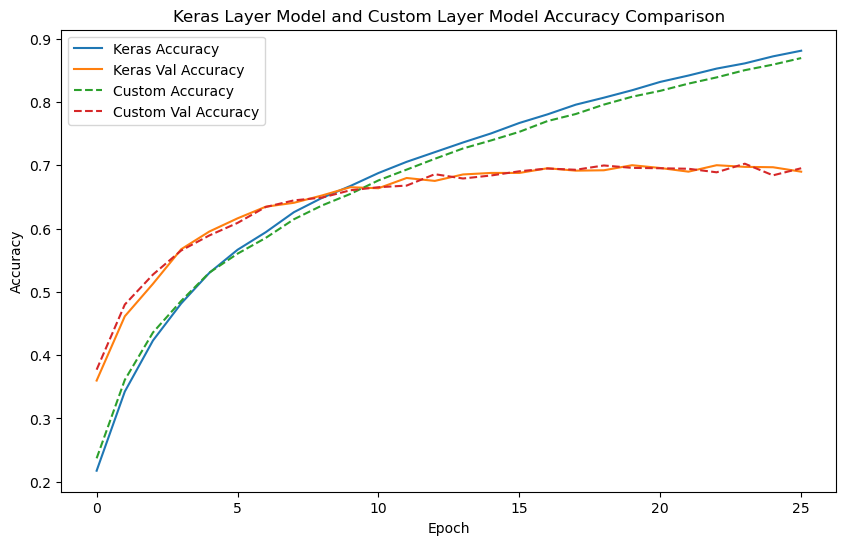

In [34]:
acc1 = pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].rename(
    columns={'accuracy': 'Keras Accuracy', 'val_accuracy': 'Keras Val Accuracy'})
acc2 = pd.DataFrame(history2.history)[['accuracy', 'val_accuracy']].rename(
    columns={'accuracy': 'Custom Accuracy', 'val_accuracy': 'Custom Val Accuracy'})

fig, ax = plt.subplots(figsize=(10, 6))

acc1.plot(ax=ax)
acc2.plot(ax=ax, linestyle='--')

ax.set_title('Keras Layer Model and Custom Layer Model Accuracy Comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend() 
plt.show()

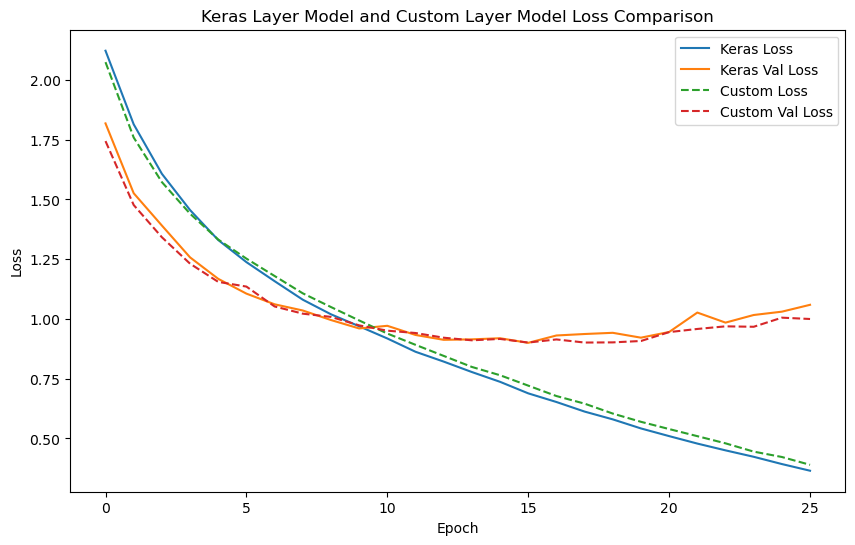

In [36]:
loss1 = pd.DataFrame(history.history)[['loss', 'val_loss']].rename(
    columns={'loss': 'Keras Loss', 'val_loss': 'Keras Val Loss'})
loss2 = pd.DataFrame(history2.history)[['loss', 'val_loss']].rename(
    columns={'loss': 'Custom Loss', 'val_loss': 'Custom Val Loss'})

fig, ax = plt.subplots(figsize=(10, 6))

loss1.plot(ax=ax)
loss2.plot(ax=ax, linestyle='--')

ax.set_title('Keras Layer Model and Custom Layer Model Loss Comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend() 
plt.show()

In [37]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


array([[0.  , 0.  , 0.01, 0.77, 0.  , 0.04, 0.01, 0.  , 0.17, 0.  ],
       [0.01, 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.96, 0.  ],
       [0.98, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  ]],
      dtype=float32)

In [38]:
X_new2 = X_test[:3]
y_proba2 = model2.predict(X_new2)
y_proba2.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[0.01, 0.  , 0.  , 0.93, 0.  , 0.02, 0.  , 0.  , 0.04, 0.  ],
       [0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  ],
       [0.37, 0.  , 0.05, 0.  , 0.  , 0.  , 0.  , 0.  , 0.57, 0.  ]],
      dtype=float32)

In [3]:
from keras.utils import plot_model

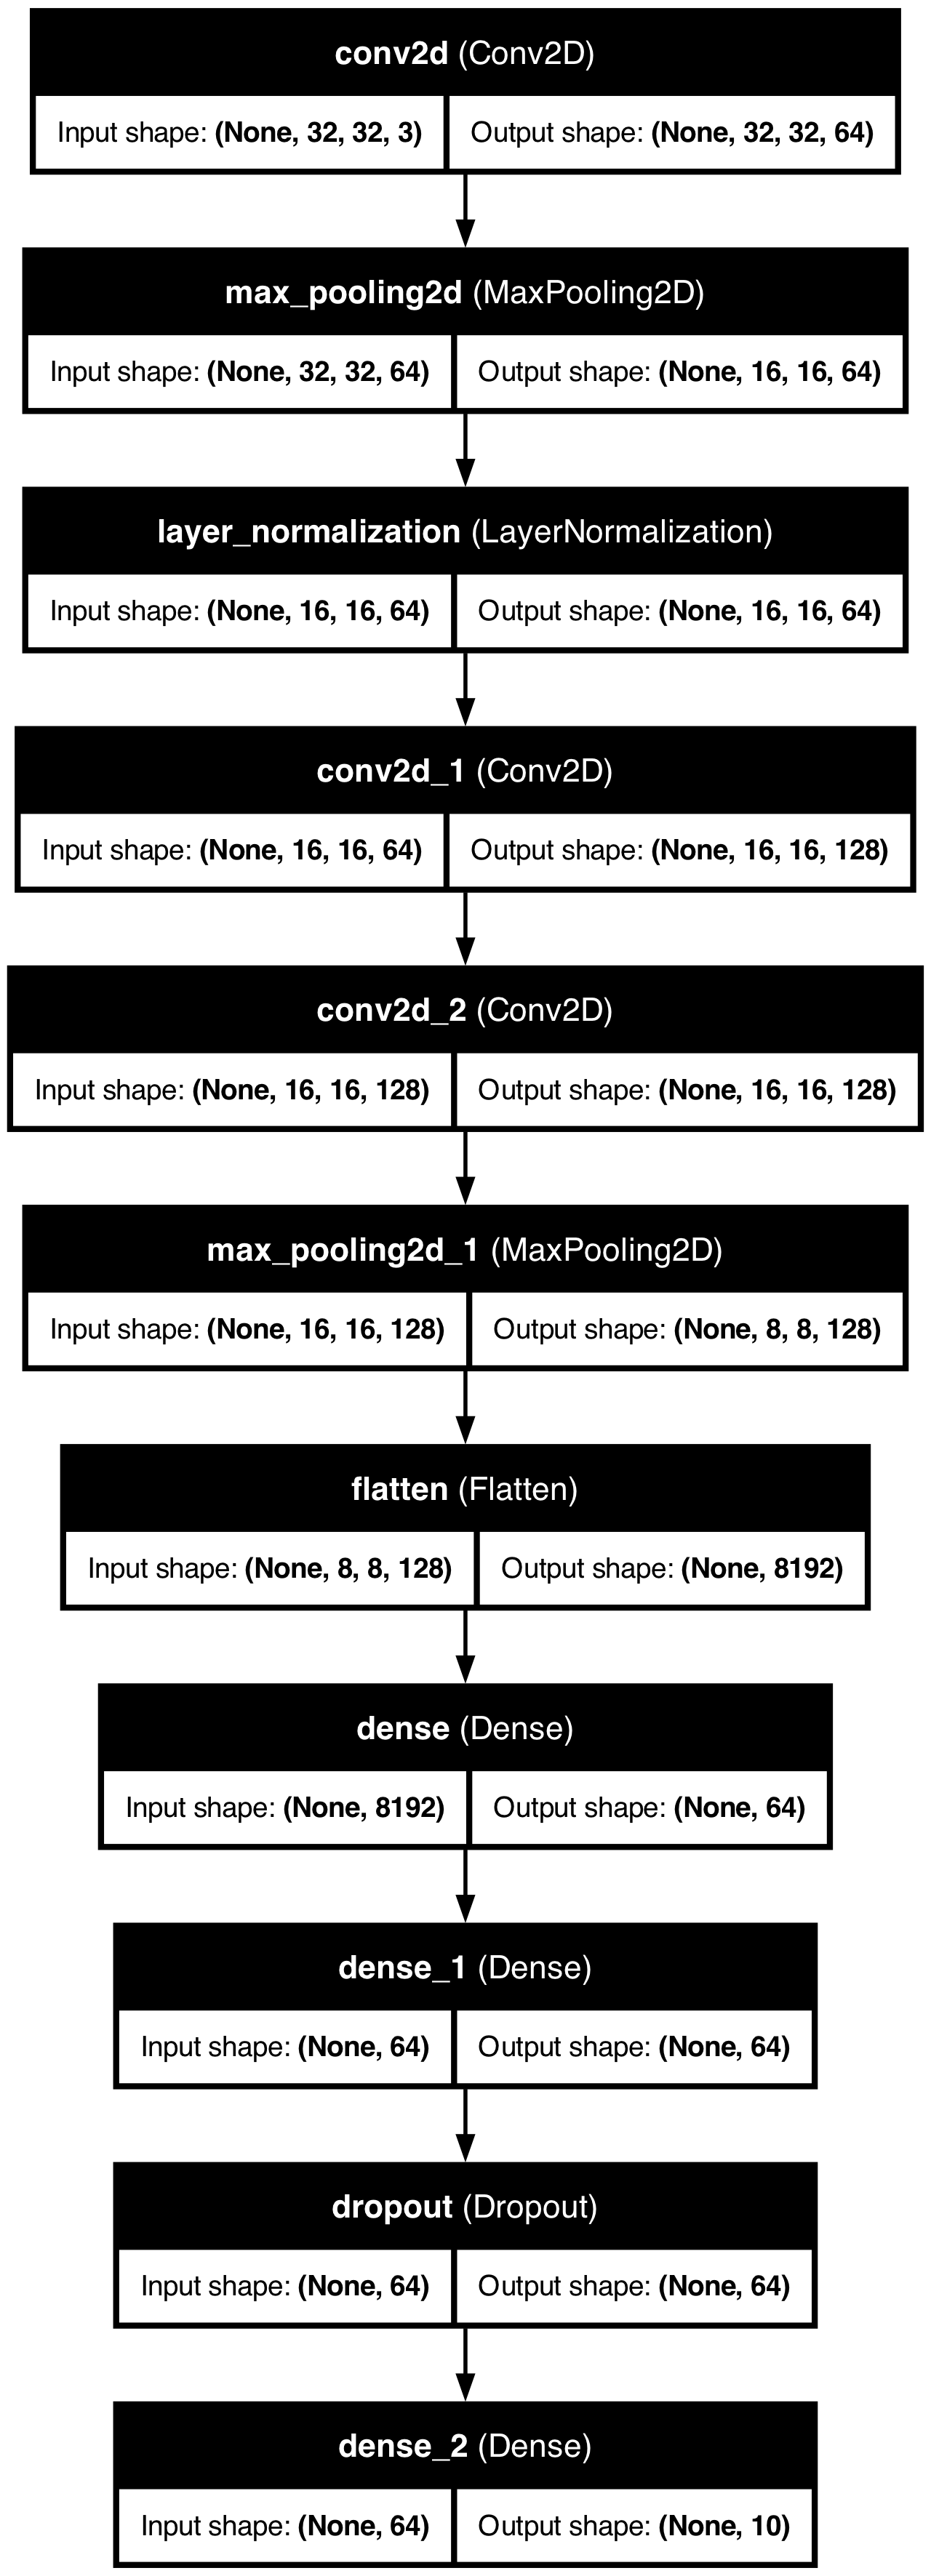

In [4]:
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

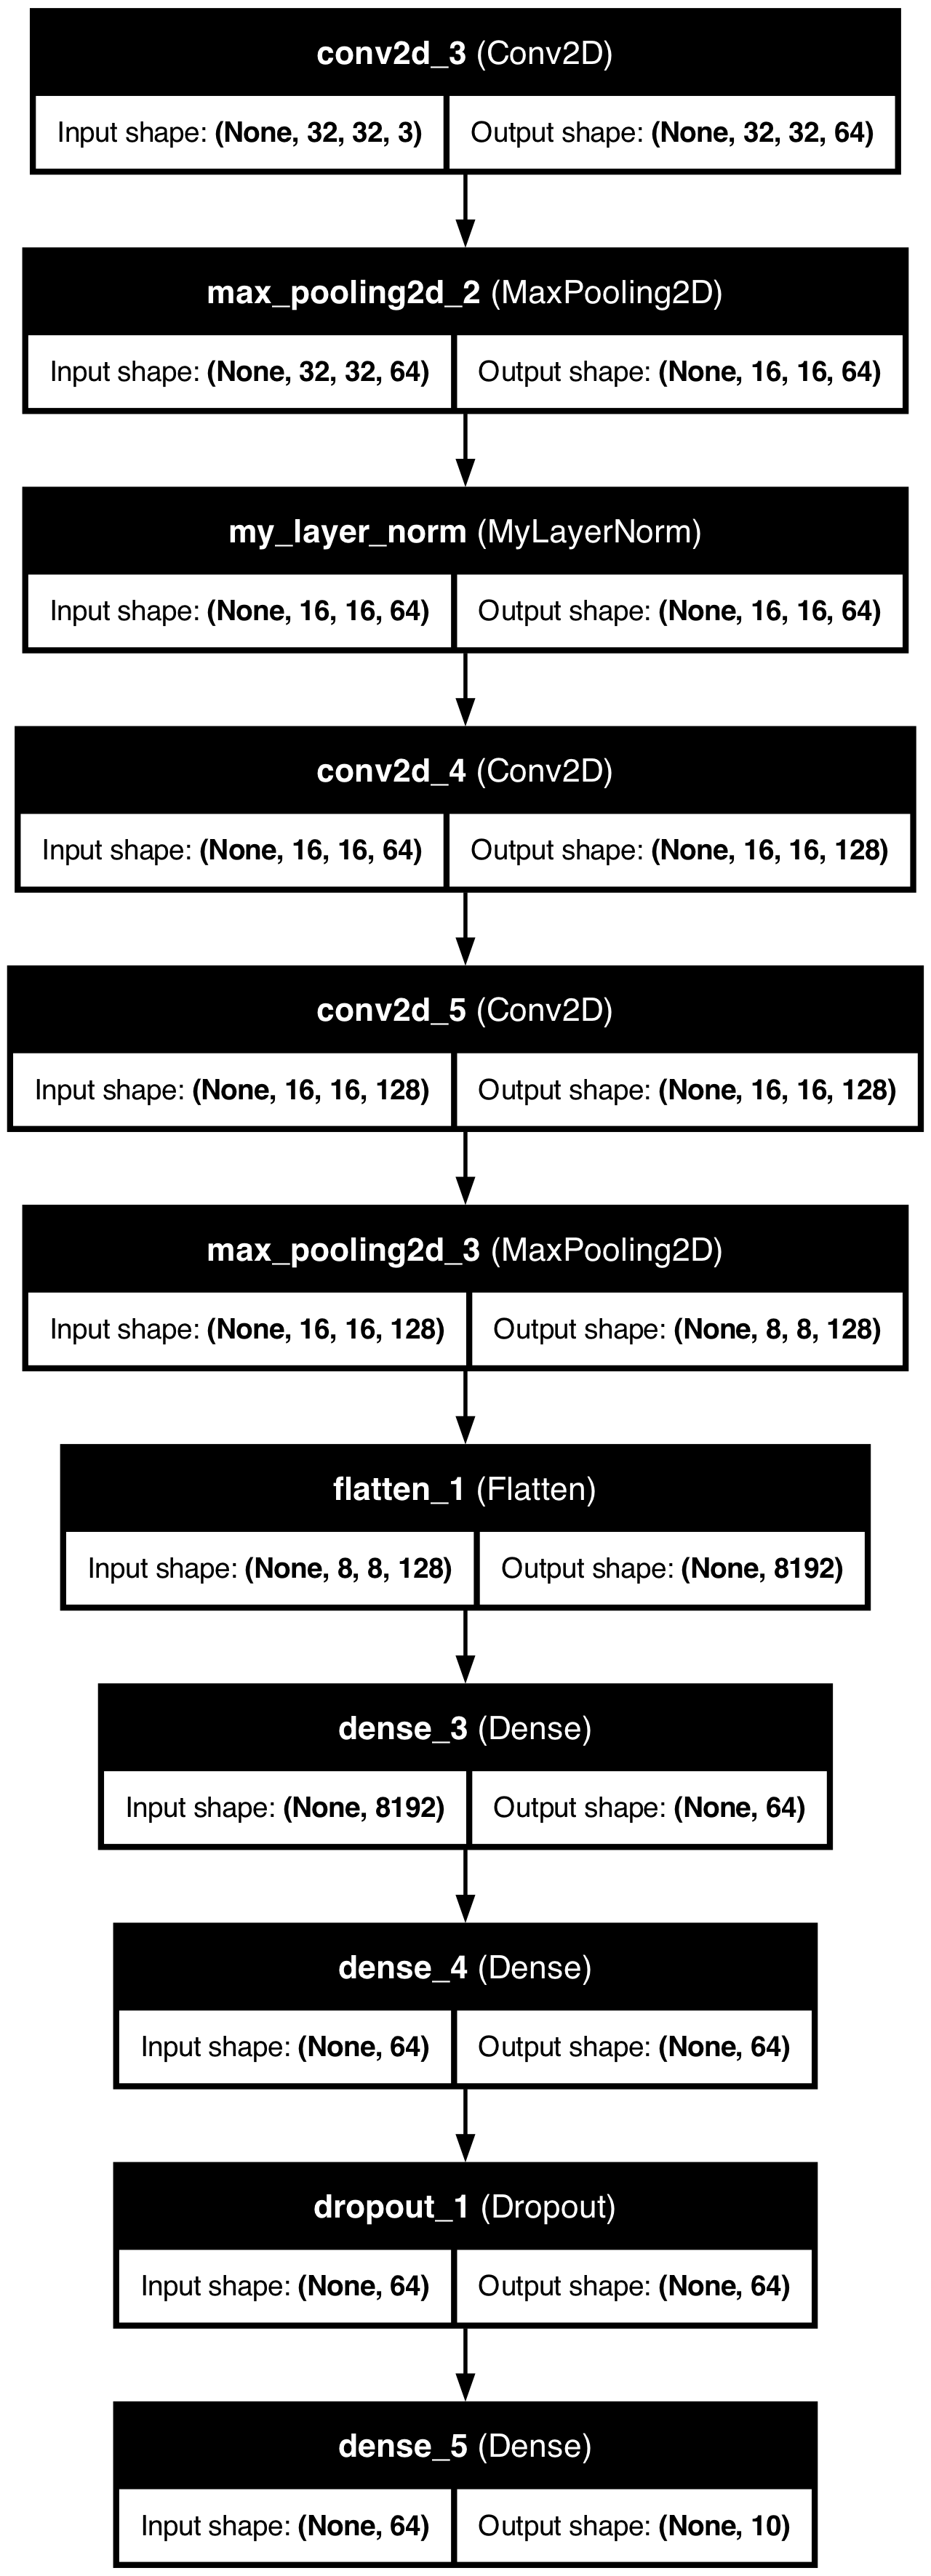

In [7]:
plot_model(model2, to_file='custommodel.png', show_shapes=True, show_layer_names=True)